# 🪔 Diwali Sales Analysis

**Objective:** Analyze Diwali sales data to understand customer demographics, purchasing behavior, product performance, and geographic/occupational sales patterns using Python.

**Tools:** Python • Pandas • NumPy • Matplotlib • Seaborn • Jupyter Notebook


## 1. Import Libraries & Load Data


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv(r"C:\Users\Abhishek\OneDrive\Documents\Diwali Sales Data.csv", encoding='unicode_escape')
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


## 2. Data Understanding & Quality Checks


In [7]:
print('Shape:', df.shape)
print(display(df.info()))
display(df.describe(include='all').T)


Shape: (11243, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11243 entries, 0 to 11242
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11243 non-null  int64  
 1   Cust_name         11243 non-null  object 
 2   Product_ID        11243 non-null  object 
 3   Gender            11243 non-null  object 
 4   Age Group         11243 non-null  object 
 5   Age               11243 non-null  int64  
 6   Marital_Status    11243 non-null  int64  
 7   State             11243 non-null  object 
 8   Zone              11243 non-null  object 
 9   Occupation        11243 non-null  object 
 10  Product_Category  11243 non-null  object 
 11  Orders            11243 non-null  int64  
 12  Amount            11240 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


None

None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,11243.0,NaN,NaN,NaN,1003004.992618,1716.141071,1000001.0,1001494.0,1003065.0,1004430.0,1006040.0
Cust_name,11243,1250,Vishakha,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,11243,2351,P00265242,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,11243,2,F,7838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age Group,11243,7,26-35,4538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,11243.0,NaN,NaN,NaN,35.422841,12.756369,12.0,27.0,33.0,43.0,92.0
Marital_Status,11243.0,NaN,NaN,NaN,0.420261,0.493623,0.0,0.0,0.0,1.0,1.0
State,11243,16,Uttar Pradesh,1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zone,11243,5,Central,4294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,11243,15,IT Sector,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Missing values and duplicate records
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Missing values:')
display(missing.to_frame('Missing_Count'))
print('Duplicate rows:', df.duplicated().sum())


Missing values:


,Missing_Count
Amount,3


Duplicate rows: 0


## 3. Data Cleaning & Preprocessing

The cleaning step removes irrelevant identifier columns, handles missing values, removes duplicate records, and validates numeric fields before analysis.


In [10]:
# Work on a copy so the raw dataframe remains available
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Drop columns that are not useful for this analysis if they exist
drop_cols = [col for col in ['Status', 'unnamed: 17', 'Unnamed: 17'] if col in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols, errors='ignore')

# Convert Amount to numeric where applicable
if 'Amount' in df_clean.columns:
    df_clean['Amount'] = pd.to_numeric(df_clean['Amount'], errors='coerce')

# Keep valid sales records
if 'Amount' in df_clean.columns:
    df_clean = df_clean[df_clean['Amount'].notna() & (df_clean['Amount'] >= 0)]

print('Cleaned dataset shape:', df_clean.shape)
display(df_clean.head())


Cleaned dataset shape: (659, 13)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [11]:
# Optional IQR-based outlier review for Amount only.
# Unlike filtering every numeric column, this avoids unintentionally removing valid Orders/Age values.
if 'Amount' in df_clean.columns:
    Q1 = df_clean['Amount'].quantile(0.25)
    Q3 = df_clean['Amount'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f'Amount IQR bounds: {lower:.2f} to {upper:.2f}')
    print('Potential Amount outliers:', ((df_clean['Amount'] < lower) | (df_clean['Amount'] > upper)).sum())


Amount IQR bounds: -12012.40 to 36076.58
Potential Amount outliers: 0


## 4. KPI Summary


In [12]:
kpis = {
    'Total Customers': df_clean['User_ID'].nunique() if 'User_ID' in df_clean.columns else np.nan,
    'Total Orders': df_clean['Orders'].sum() if 'Orders' in df_clean.columns else np.nan,
    'Total Sales': df_clean['Amount'].sum() if 'Amount' in df_clean.columns else np.nan,
    'Average Order Value': df_clean['Amount'].mean() if 'Amount' in df_clean.columns else np.nan
}
display(pd.Series(kpis, name='Value').to_frame())


,Value
Total Customers,5.720000e+02
Total Orders,1.631000e+03
Total Sales,7.930390e+06
Average Order Value,1.203398e+04


## 5. Customer Demographics & Purchase Behavior


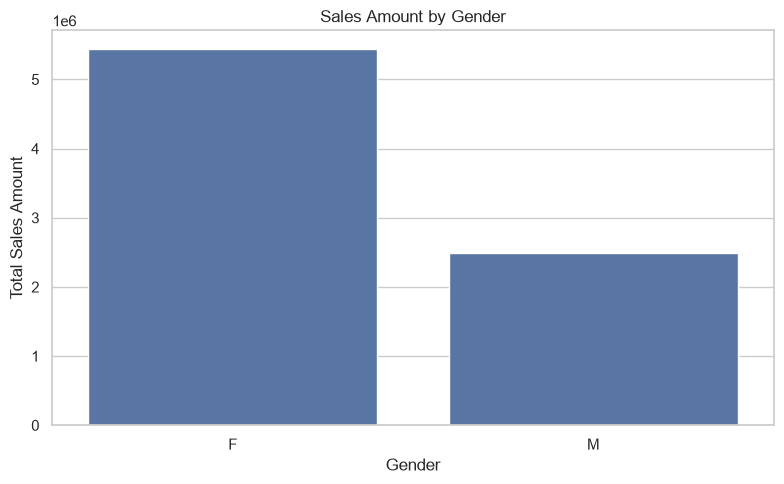

In [13]:
# Gender-wise sales
gender_sales = df_clean.groupby('Gender', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=gender_sales, x='Gender', y='Amount', errorbar=None)
plt.title('Sales Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()


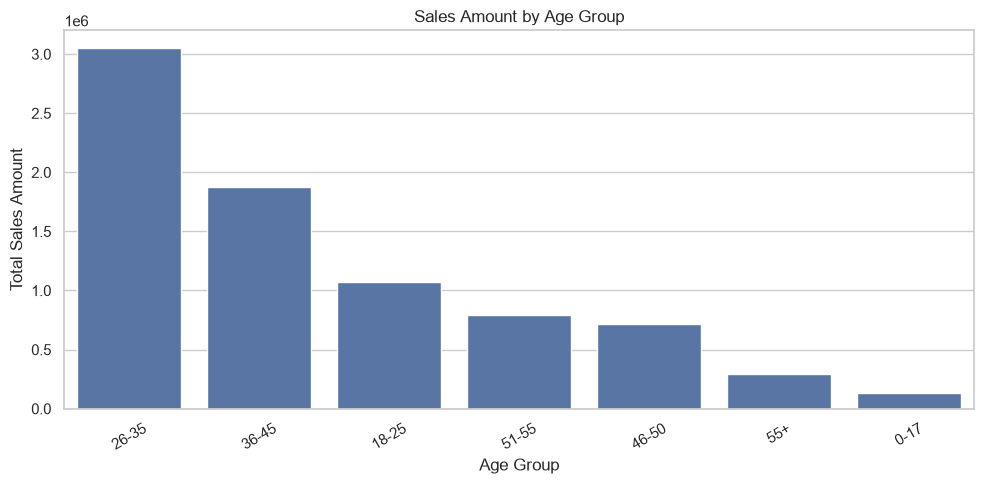

In [14]:
# Age group-wise sales
age_sales = df_clean.groupby('Age Group', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=age_sales, x='Age Group', y='Amount', errorbar=None)
plt.title('Sales Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


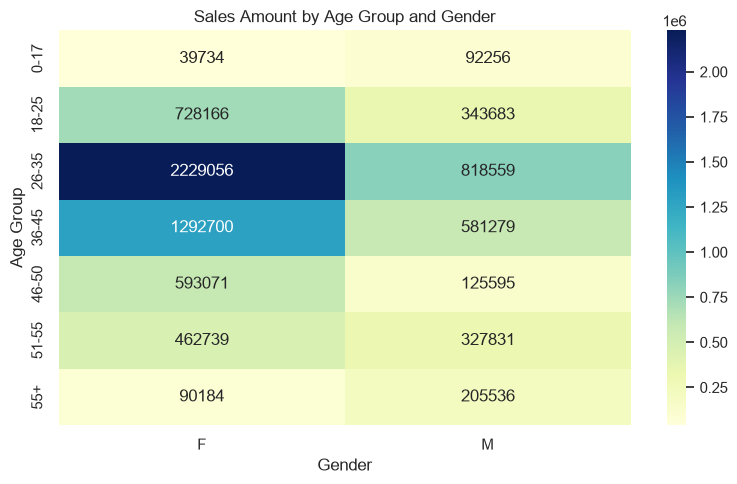

In [15]:
# Age Group × Gender heatmap
age_gender = pd.pivot_table(
    df_clean,
    values='Amount',
    index='Age Group',
    columns='Gender',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(8,5))
sns.heatmap(age_gender, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales Amount by Age Group and Gender')
plt.xlabel('Gender')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()


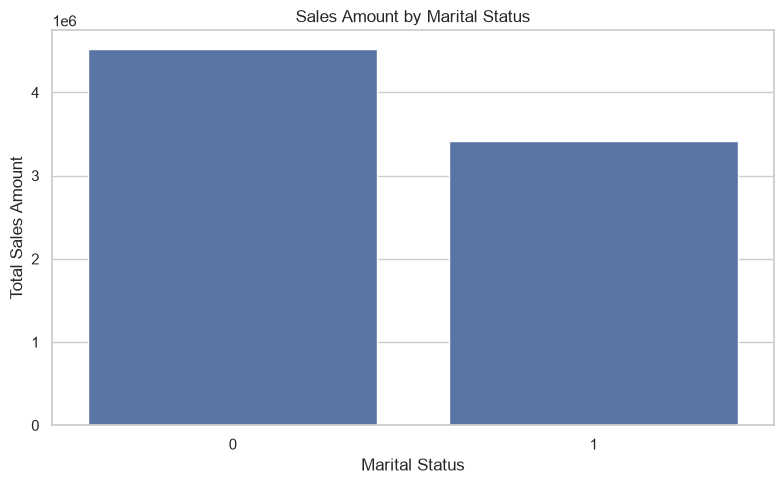

In [16]:
# Marital status-wise sales
marital_sales = df_clean.groupby('Marital_Status', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=marital_sales, x='Marital_Status', y='Amount', errorbar=None)
plt.title('Sales Amount by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()


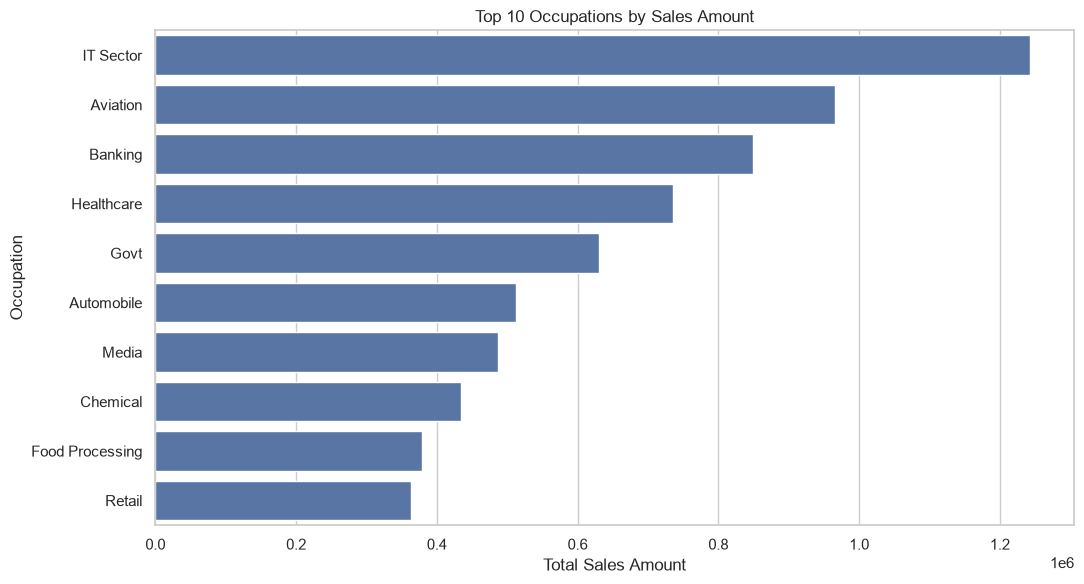

In [17]:
# Occupation-wise sales — Top 10
occupation_sales = (
    df_clean.groupby('Occupation', as_index=False)['Amount']
    .sum()
    .sort_values('Amount', ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))
sns.barplot(data=occupation_sales, x='Amount', y='Occupation', errorbar=None)
plt.title('Top 10 Occupations by Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()


## 6. Geographic Sales Analysis


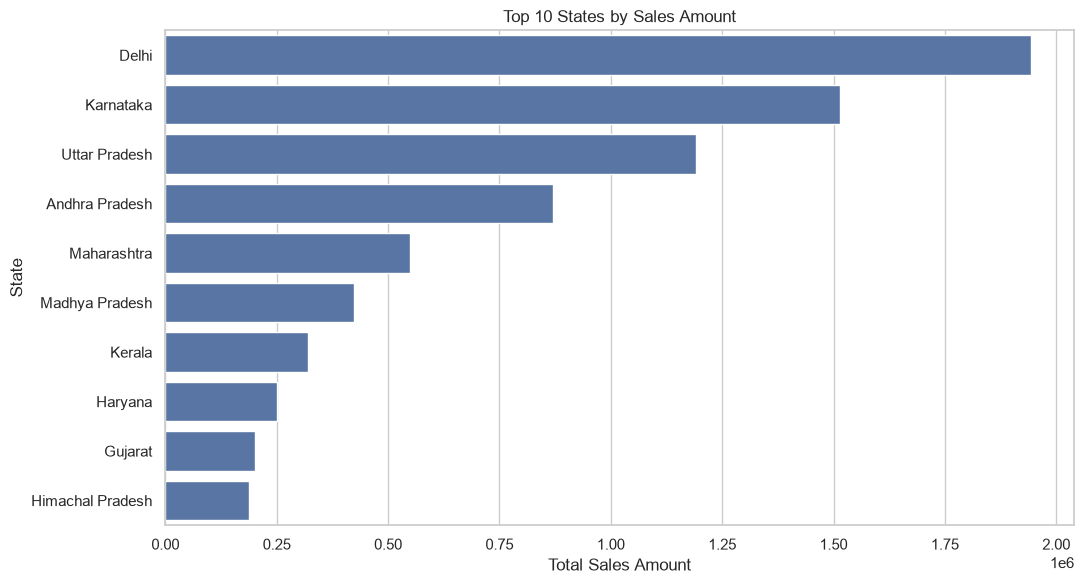

In [18]:
# State-wise sales — Top 10
state_sales = (
    df_clean.groupby('State', as_index=False)['Amount']
    .sum()
    .sort_values('Amount', ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))
sns.barplot(data=state_sales, x='Amount', y='State', errorbar=None)
plt.title('Top 10 States by Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()


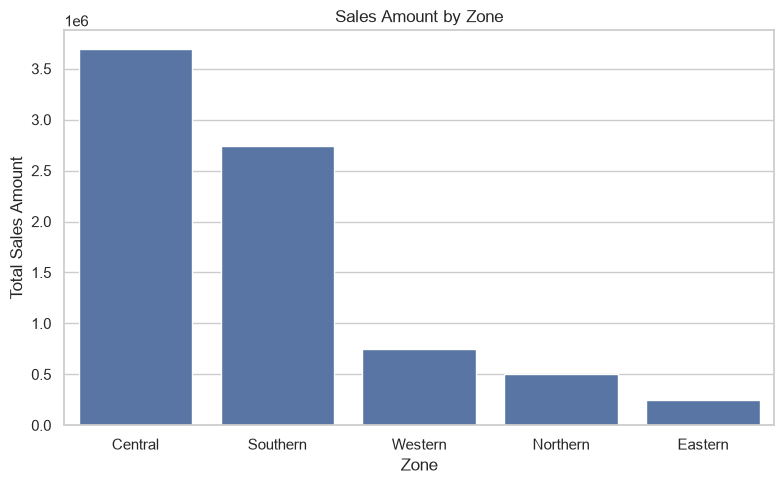

In [19]:
# Zone-wise sales
zone_sales = df_clean.groupby('Zone', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=zone_sales, x='Zone', y='Amount', errorbar=None)
plt.title('Sales Amount by Zone')
plt.xlabel('Zone')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()


## 7. Product Performance


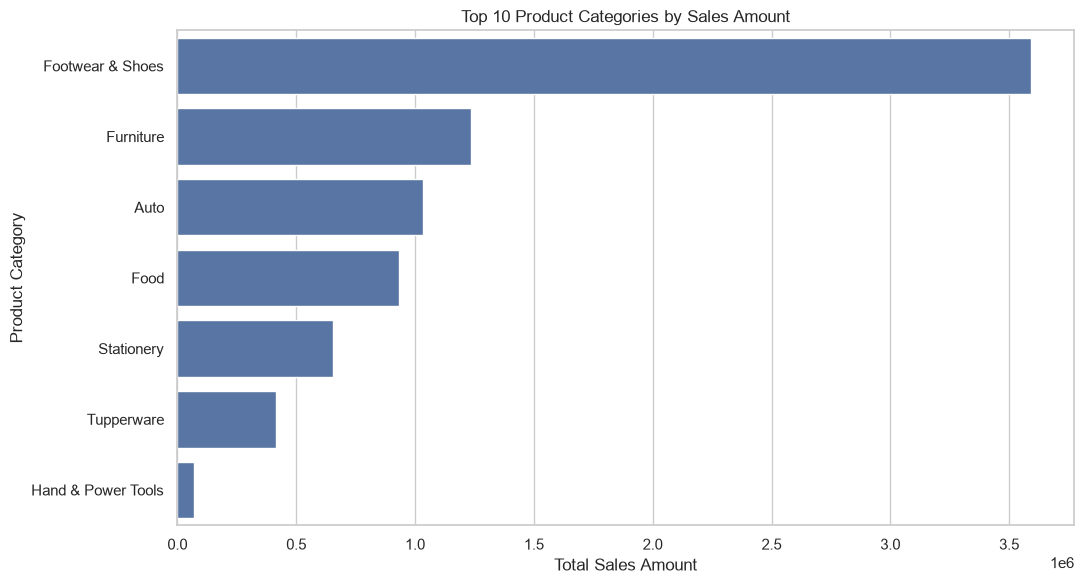

In [20]:
# Product category by total sales
category_sales = (
    df_clean.groupby('Product_Category', as_index=False)['Amount']
    .sum()
    .sort_values('Amount', ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))
sns.barplot(data=category_sales, x='Amount', y='Product_Category', errorbar=None)
plt.title('Top 10 Product Categories by Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


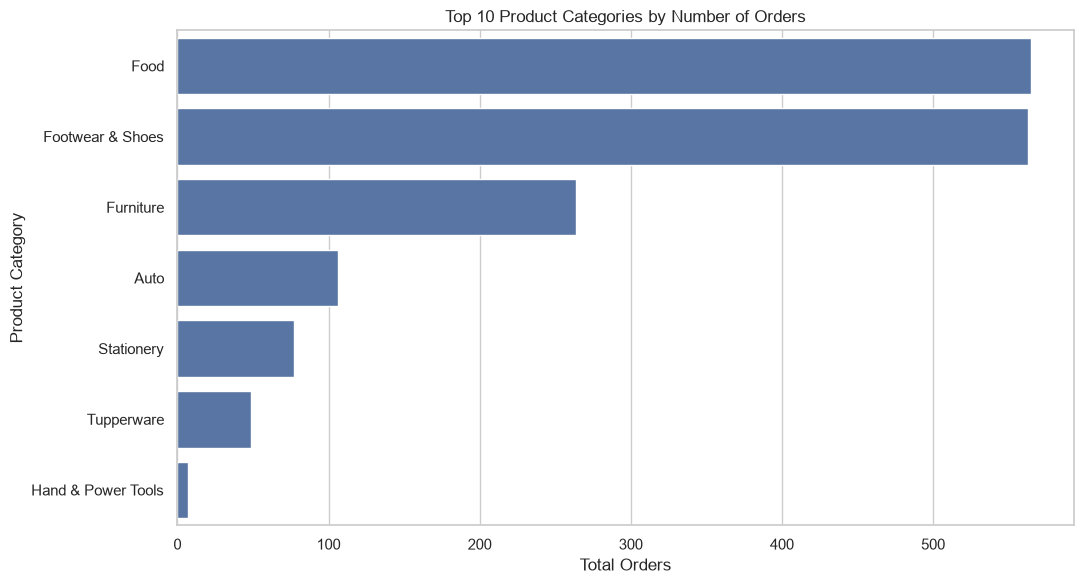

In [21]:
# Product category by number of orders
category_orders = (
    df_clean.groupby('Product_Category', as_index=False)['Orders']
    .sum()
    .sort_values('Orders', ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))
sns.barplot(data=category_orders, x='Orders', y='Product_Category', errorbar=None)
plt.title('Top 10 Product Categories by Number of Orders')
plt.xlabel('Total Orders')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


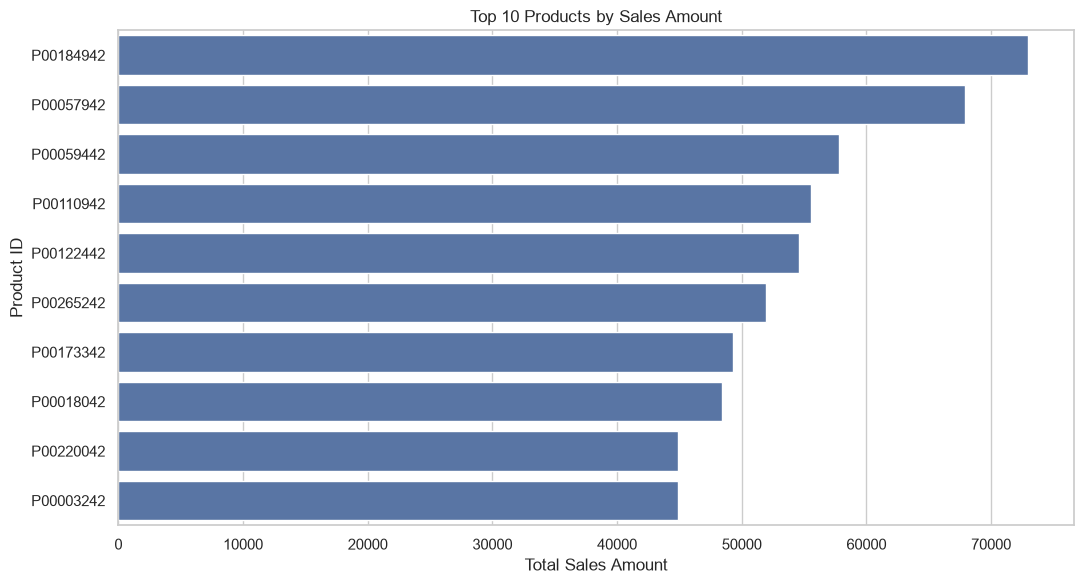

In [22]:
# Top 10 products by sales amount, if Product_ID and Amount are available
if {'Product_ID', 'Amount'}.issubset(df_clean.columns):
    top_products = (
        df_clean.groupby('Product_ID', as_index=False)['Amount']
        .sum()
        .sort_values('Amount', ascending=False)
        .head(10)
    )

    plt.figure(figsize=(11,6))
    sns.barplot(data=top_products, x='Amount', y='Product_ID', errorbar=None)
    plt.title('Top 10 Products by Sales Amount')
    plt.xlabel('Total Sales Amount')
    plt.ylabel('Product ID')
    plt.tight_layout()
    plt.show()


## 8. Sales Distribution & Relationship Analysis


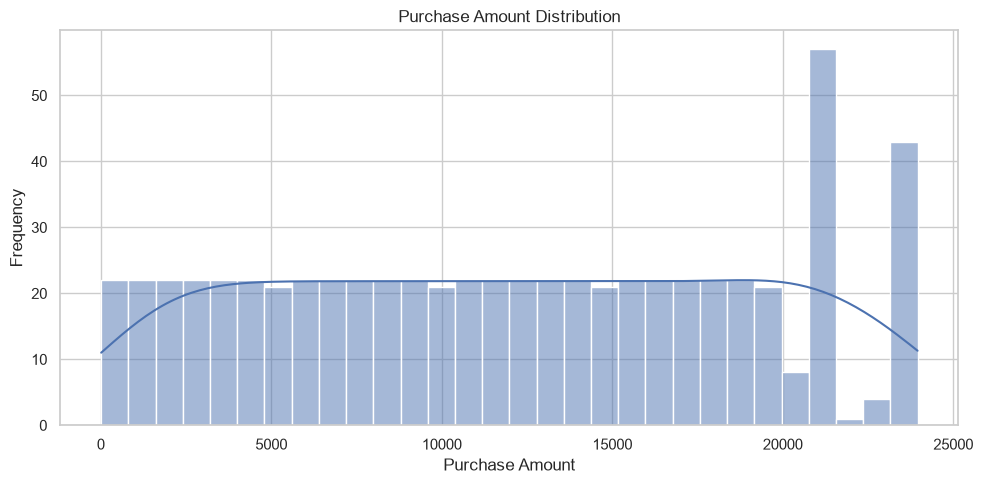

In [23]:
# Purchase amount distribution
plt.figure(figsize=(10,5))
sns.histplot(df_clean['Amount'], bins=30, kde=True)
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


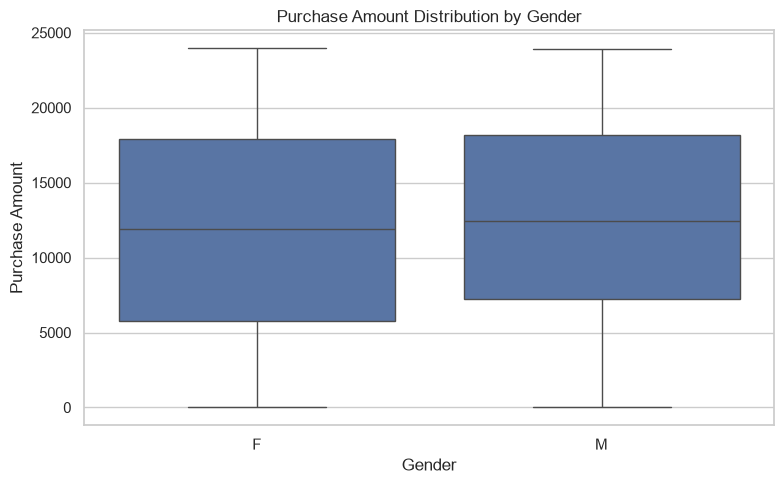

In [24]:
# Purchase amount distribution by gender
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Gender', y='Amount')
plt.title('Purchase Amount Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.tight_layout()
plt.show()


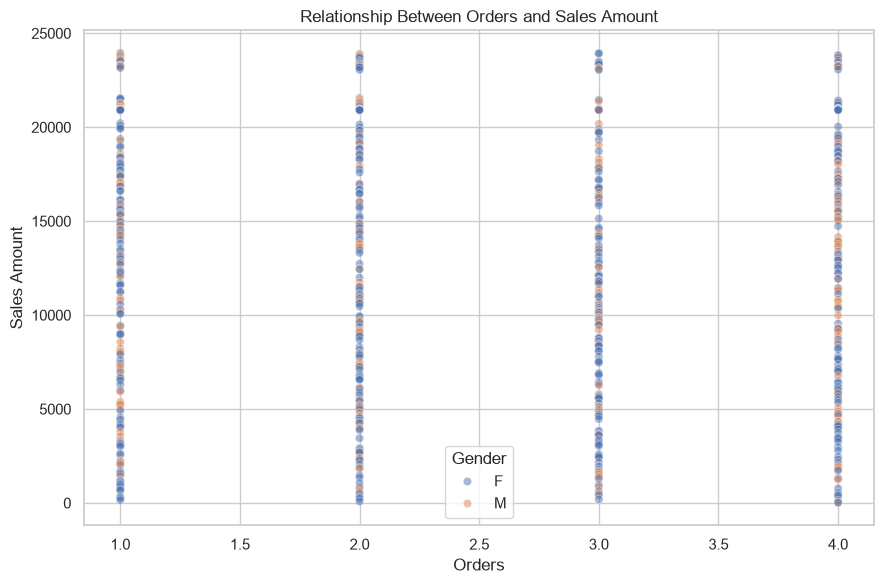

In [25]:
# Orders vs Amount
if {'Orders', 'Amount'}.issubset(df_clean.columns):
    plt.figure(figsize=(9,6))
    sns.scatterplot(data=df_clean, x='Orders', y='Amount', hue='Gender', alpha=0.5)
    plt.title('Relationship Between Orders and Sales Amount')
    plt.xlabel('Orders')
    plt.ylabel('Sales Amount')
    plt.tight_layout()
    plt.show()


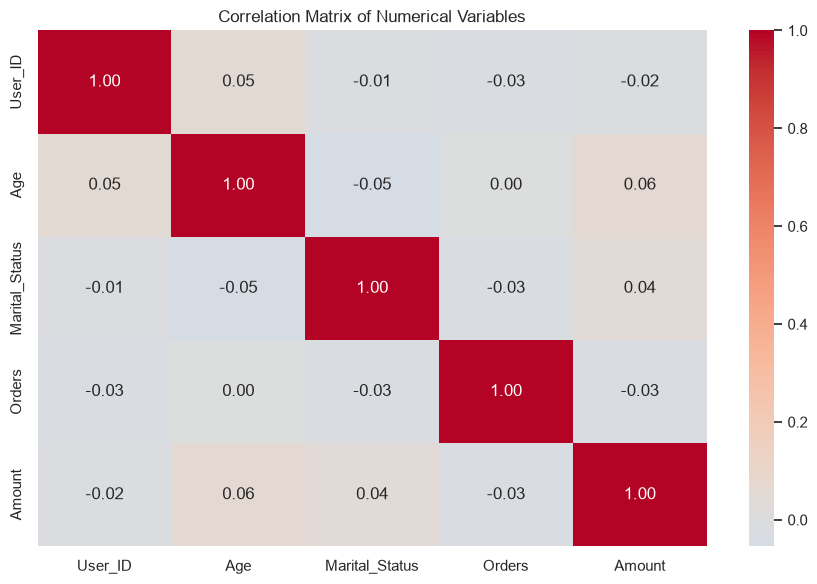

In [26]:
# Correlation heatmap for numerical variables
numeric_cols = df_clean.select_dtypes(include=np.number).columns
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()


## 9. Summary Tables for Business Insights

These tables make the analysis easier to interpret and can be used to support business recommendations.

In [27]:
summary = {
    'Top State': state_sales.iloc[0]['State'] if not state_sales.empty else None,
    'Top Age Group': age_sales.iloc[0]['Age Group'] if not age_sales.empty else None,
    'Top Occupation': occupation_sales.iloc[0]['Occupation'] if not occupation_sales.empty else None,
    'Top Product Category by Sales': category_sales.iloc[0]['Product_Category'] if not category_sales.empty else None
}
display(pd.Series(summary, name='Result').to_frame())


,Result
Top State,Delhi
Top Age Group,26-35
Top Occupation,IT Sector
Top Product Category by Sales,Footwear & Shoes


## 10. Key Takeaways

Use the generated charts and summary tables to document the actual findings from the cleaned dataset. Avoid hard-coding conclusions before reviewing the updated results.

### Skills Demonstrated
- Data cleaning and preprocessing with Pandas
- Exploratory Data Analysis (EDA)
- GroupBy, aggregation and pivot-table analysis
- Customer segmentation by demographics
- Product and geographic sales analysis
- Data visualization with Matplotlib and Seaborn
- Basic statistical/outlier analysis
- Business-oriented interpretation of sales data


In [29]:
# Save the cleaned dataset for reuse
df_clean.to_csv(r"C:\Users\Abhishek\OneDrive\Documents\Diwali Sales Data.csv", index=False)
print('Cleaned dataset saved successfully.')


Cleaned dataset saved successfully.
